# HEART DISEASE PREDICTION - COMPLETE PROJECT
# Dataset: Heart Disease UCI Multi-Country

# STEP 1 -  IMPORT libraries

In [80]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix, roc_auc_score

# STEP 2 - LOAD DATA

data = pd.read_csv('heart_disease_uci.csv')

print("Shape:", data.shape)
print("\nFirst 5 rows:")
data.head()

Shape: (920, 16)

First 5 rows:


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


# STEP 3 - BASIC EDA

In [81]:

# Basic Info
print("Dataset Info:")
print(data.info())

print("\nBasic Statistics:")
print(data.describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB
None

Basic Statistics:
               id         age    trestbps        chol      thalch     oldpeak  \
count  920

# STEP 4 - TARGET COLUMN - num

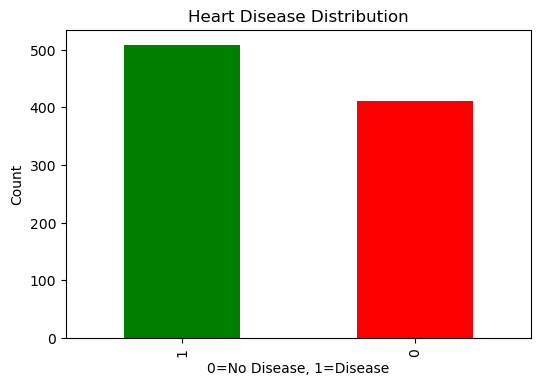

target
1    509
0    411
Name: count, dtype: int64


In [82]:

data['target'] = data['num'].apply(lambda x: 1 if x > 0 else 0)
data.drop(['num', 'id', 'dataset','ca'], axis=1, inplace=True)

# Target Distribution Plot
plt.figure(figsize=(6,4))
data['target'].value_counts().plot(kind='bar', color=['green','red'])
plt.title('Heart Disease Distribution')
plt.xlabel('0=No Disease, 1=Disease')
plt.ylabel('Count')
plt.show()

print(data['target'].value_counts())

In [83]:
# Numerical - Median se fill
data['trestbps'] = data['trestbps'].fillna(data['trestbps'].median())
data['chol'] = data['chol'].fillna(data['chol'].median())
data['thalch'] = data['thalch'].fillna(data['thalch'].median())
data['oldpeak'] = data['oldpeak'].fillna(data['oldpeak'].median())

# Categorical - Mode se fill
data['fbs'] = data['fbs'].fillna(data['fbs'].mode()[0])
data['restecg'] = data['restecg'].fillna(data['restecg'].mode()[0])
data['exang'] = data['exang'].fillna(data['exang'].mode()[0])
data['slope'] = data['slope'].fillna(data['slope'].mode()[0])
data['thal'] = data['thal'].fillna(data['thal'].mode()[0])


print(data.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
target      0
dtype: int64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_16176\277410126.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['fbs'] = data['fbs'].fillna(data['fbs'].mode()[0])
C:\Users\ASUS\AppData\Local\Temp\ipykernel_16176\277410126.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['exang'] = data['exang'].fillna(data['exang'].mode()[0])


# STEP 6 - ENCODING

In [84]:


# Sex(Gender) encode
data['sex'] = data['sex'].map({'Male': 1, 'Female': 0})

# Chest Pain encode
data['cp'] = data['cp'].map({
    'asymptomatic': 0,
    'atypical angina': 1,
    'non-anginal': 2,
    'typical angina': 3
})

# RestECG encode
data['restecg'] = data['restecg'].map({
    'normal': 0,
    'st-t abnormality': 1,
    'lv hypertrophy': 2
})

# Slope encode
data['slope'] = data['slope'].map({
    'upsloping': 0,
    'flat': 1,
    'downsloping': 2
})

# Thal encode
data['thal'] = data['thal'].map({
    'normal': 0,
    'fixed defect': 1,
    'reversable defect': 2
})
print(data.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
target      0
dtype: int64


# STEP 7 - OUTLIER HANDLING

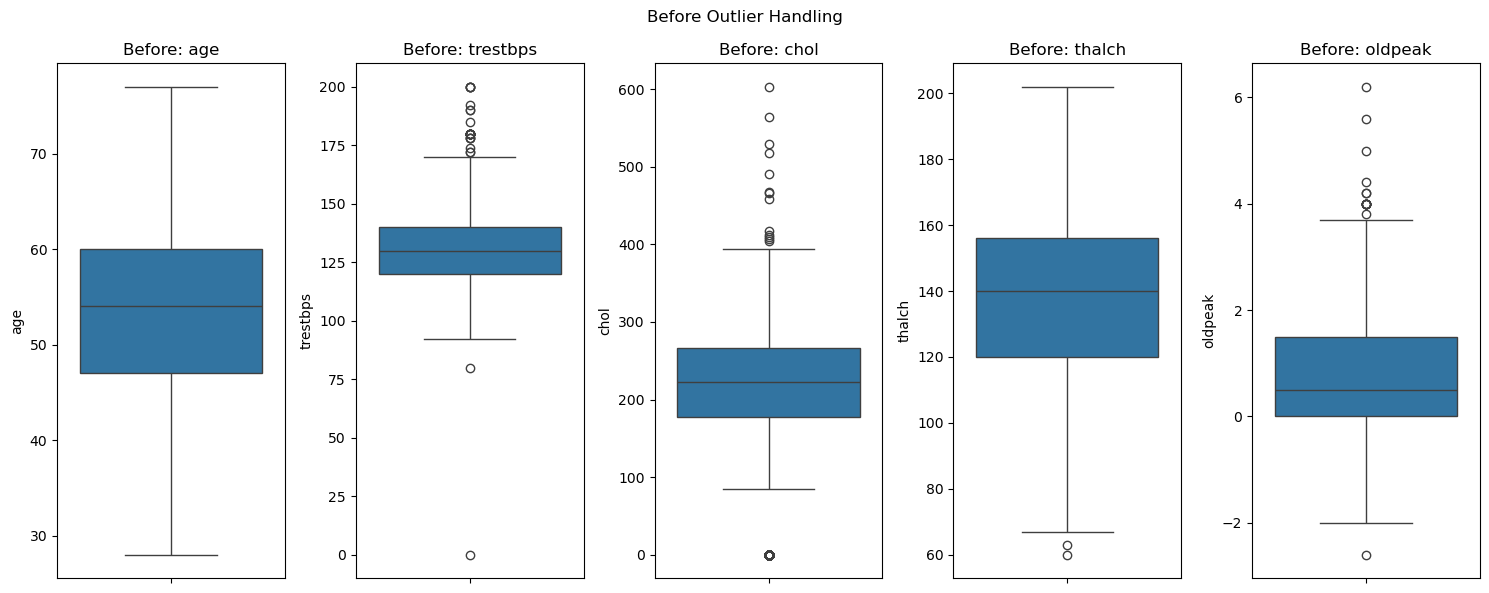

In [85]:


def cap_outliers(col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    data[col] = data[col].clip(lower, upper)

# Outliers se pehle boxplot
numerical = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
plt.figure(figsize=(15,6))
for i, col in enumerate(numerical):
    plt.subplot(1, 5, i+1)
    sns.boxplot(y=data[col])
    plt.title(f'Before: {col}')
plt.suptitle('Before Outlier Handling')
plt.tight_layout()
plt.show()

# Outliers cap karo
for col in ['trestbps', 'chol', 'thalch', 'oldpeak']:
    cap_outliers(col)


# STEP 8 - FEATURE ENGINEERING

In [86]:


# Age Groups
data['age_group'] = pd.cut(data['age'],
                    bins=[0, 40, 55, 70, 100],
                    labels=['Young', 'Middle', 'Senior', 'Old'])

# BP Category
data['bp_category'] = pd.cut(data['trestbps'],
                    bins=[0, 120, 140, 200],
                    labels=['Normal', 'PreHigh', 'High'])

# Risk Score
data['risk_score'] = data['age'] + data['chol']/10 + data['trestbps']/10

# Get Dummies
data = pd.get_dummies(data, columns=['age_group', 'bp_category'],
                      drop_first=True)

print("New Shape:", data.shape)

New Shape: (920, 19)


# STEP 9 - CORRELATION HEATMAP

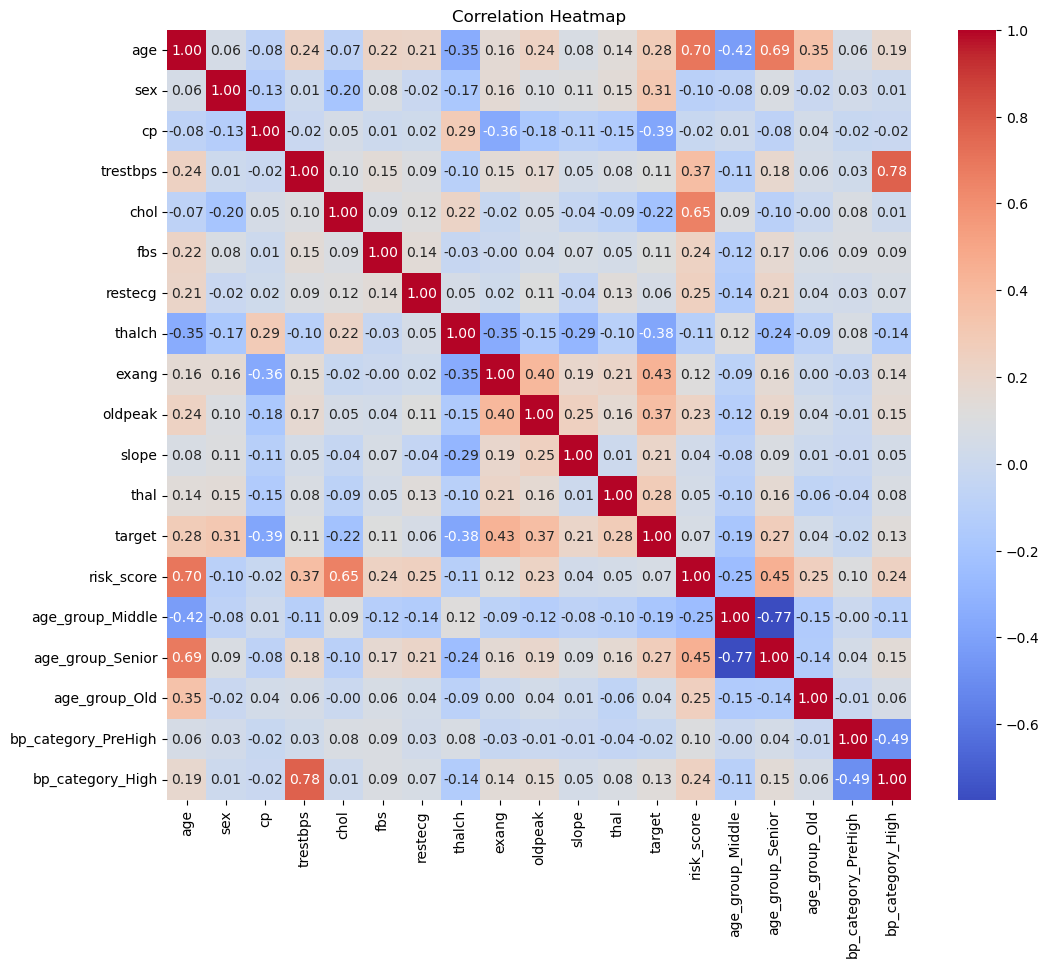

In [87]:


plt.figure(figsize=(12,10))
sns.heatmap(data.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# STEP 10 - MODEL TRAINING

In [88]:


X = data.drop('target', axis=1)
y = data['target']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling using standardscaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# 1. Logistic Regression
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)

# 2. Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 3. XGBoost
xgb = XGBClassifier(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


# STEP 11 - MODEL EVALUATION

Logistic Regression : Accuracy=0.82 | ROC-AUC=0.82
Random Forest       : Accuracy=0.85 | ROC-AUC=0.85
XGBoost             : Accuracy=0.84 | ROC-AUC=0.85

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.87      0.82        75
           1       0.90      0.83      0.86       109

    accuracy                           0.84       184
   macro avg       0.84      0.85      0.84       184
weighted avg       0.85      0.84      0.84       184



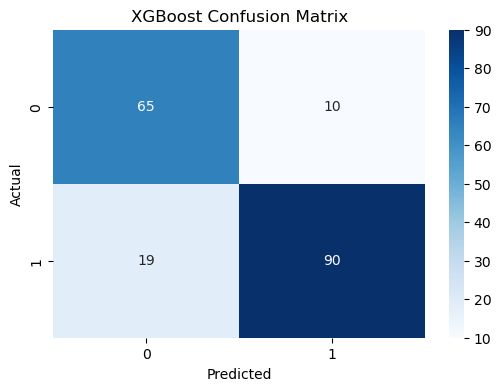

In [89]:


# Predictions
lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)
xgb_pred = xgb.predict(X_test)

# Model Comparison
print(f"Logistic Regression : Accuracy={accuracy_score(y_test, lr_pred):.2f} | ROC-AUC={roc_auc_score(y_test, lr_pred):.2f}")
print(f"Random Forest       : Accuracy={accuracy_score(y_test, rf_pred):.2f} | ROC-AUC={roc_auc_score(y_test, rf_pred):.2f}")
print(f"XGBoost             : Accuracy={accuracy_score(y_test, xgb_pred):.2f} | ROC-AUC={roc_auc_score(y_test, xgb_pred):.2f}")

# Best Model Report
print("\nXGBoost Classification Report:")
print(classification_report(y_test, xgb_pred))

# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, xgb_pred),
            annot=True, fmt='d', cmap='Blues')
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()